# Project: Neutrino Portal at the Muon Collider

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import pathlib
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import json

## Load Events

-  this function reads the particles in a csv file and exports a data frame

In [2]:
data= pd.read_csv('output_events_CC_numu/events_112.94.csv.zip')

In [3]:
data

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,12,0,112.94,13,-0.636,1.241,81.198,81.210,14,1
1,12,1,112.94,2212,0.327,-0.392,1.815,2.106,2214,90
2,12,2,112.94,-13,0.103,0.687,5.687,5.730,411,90
3,12,3,112.94,14,0.374,-0.157,3.223,3.248,411,90
4,12,4,112.94,22,-0.205,0.073,2.072,2.083,111,90
...,...,...,...,...,...,...,...,...,...,...
25139,200910,15,112.94,22,0.113,-0.092,1.603,1.610,111,90
25140,200910,16,112.94,22,0.086,0.226,4.481,4.488,111,90
25141,200910,17,112.94,22,0.230,0.195,5.769,5.777,111,90
25142,200910,18,112.94,22,-0.026,0.036,2.190,2.191,111,90


- function that evaulates all necessary obseravbles for each event

In [4]:
def calculate_observables(data):
    events = []
    grouped_data = data.groupby('ievent')

    for ievent, evt in grouped_data:
        # Reset or initialize variables for each event
        e_mu_minus, e_mu_plus, has_charm, e_em, e_visible, ptx, pty, ht = 0, 0, 0, 0, 0, 0, 0, 0
        
        # Iterate over particles in the event
        for _, row in evt.iterrows():
            truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
            parent_pid1 = row[8]
            
            # Check for charm particles
            if abs(parent_pid1) in {411, 421, 431, 4122}: 
                has_charm = 1
            
            # Update energies for mu- and mu+
            if pid == 13: e_mu_minus = max(e, e_mu_minus)
            elif pid == -13: e_mu_plus = max(e, e_mu_plus)
            
            # Sum EM and visible energy
            if abs(pid) in {22, 11}: 
                e_em += e
            if abs(pid) not in {12, 14, 16}: 
                e_visible += e
                ptx += px
                pty += py
                ht += np.sqrt(px**2 + py**2)
        
        # Calculate missing pT
        pt_mis = -np.sqrt(ptx**2 + pty**2)
        
        # Append event observables
        events.append([ievent, truth_energy, e_mu_minus, e_mu_plus, has_charm, e_visible, pt_mis, ht])

    # Construct DataFrame from results
    columns = ['ievent', 'truth_energy', 'e_mu_minus', 'e_mu_plus', 'has_charm', 'e_visible', 'pt_mis', 'ht']
    observables = pd.DataFrame(events, columns=columns)
    
    return observables


In [5]:
%%time
observables = calculate_observables(data)

CPU times: user 2.43 s, sys: 34 ms, total: 2.46 s
Wall time: 2.5 s


In [6]:
observables

,ievent,truth_energy,e_mu_minus,e_mu_plus,has_charm,e_visible,pt_mis,ht
0,12,112.94,81.210,5.730,1,110.648,-0.404695,5.280341
1,23,112.94,10.830,38.103,1,82.346,-1.076315,7.156739
2,190,112.94,82.386,5.235,1,108.225,-0.524742,5.183489
3,513,112.94,14.305,4.225,1,96.296,-0.091285,8.005864
4,544,112.94,98.310,5.743,1,109.675,-0.695690,3.864772
...,...,...,...,...,...,...,...,...
1982,200504,112.94,29.970,9.871,1,88.260,-0.304573,7.405631
1983,200568,112.94,24.860,5.312,1,113.711,-0.071505,7.704145
1984,200655,112.94,1.916,6.760,1,90.124,-0.353345,4.935974
1985,200727,112.94,16.396,34.714,1,104.337,-0.693098,5.278884


<AxesSubplot:xlabel='e_mu_minus', ylabel='Count'>

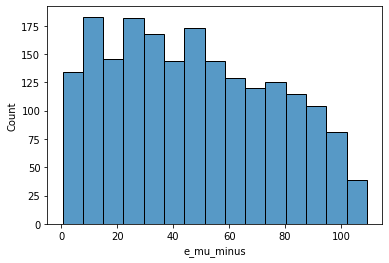

In [7]:
sns.histplot(observables, x='e_mu_minus')

- load all events 

**Add explaination for file format of MC_-14_3TeV_with_cut_with_final.txt: please explain what the new file MC_-14_3TeV_with_cut_with_final.txt contains. (including units, and where these numbers come from)**

**Explain how the weights are calculated (so type some formulas, references, ...)**

In [8]:
def load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final.txt'):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g 
    l_det = 4.0425         # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2
    nevent = 1e7           # No. of MC events 

    #initialize output 
    all_data = None
    
    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 
    scaling_data['energy'] = round(scaling_data['energy'],0)
    
    #loop over datasets 
    datasets = ['NC_nuebar', 'CC_nuebar', 'CC_numu', 'NC_numu']
    for dataset in datasets:
        
        # get all files and loop over them
        dirname = 'output_events_' + dataset  
        directory = pathlib.Path(dirname)
        files = sorted(directory.rglob('events_*.csv.zip'))
        
        #import data on generated event rates
        generated_data_name = dirname+"/generated_events.json"
        with open(generated_data_name, "r") as f: generated_data_raw = json.load(f)
        generated_data = {int(float(key)): value for key, value in generated_data_raw.items()}

        for file in files:
            #logging
            print("load file: "+ str(file))
            
            # get beam energy
            energy = float(str(file).split('_')[-1].replace('.csv.zip', ''))
                
            # load data, get observables
            data = pd.read_csv(str(file))
            observables = calculate_observables(data)
            observables['set'] = dataset
            
            ### obtain number of events (allows for different nevents for different energies)
            nevent = generated_data[int(energy)]
            
            # calculate scaling factor            
            scaling_row = scaling_data[scaling_data['energy'] == round(energy,0)]
            
            cross_section = scaling_row[dataset].values[0]
            flux = scaling_row[dataset[3:]+"_flux"].values[0]  
            weight = ((cross_section * flux * mul)/nevent)   
            observables['weight'] = weight
            
            # combine data
            if all_data is None:all_data = observables
            else:all_data = pd.concat([all_data, observables])
    
    return all_data.reset_index(drop=True)


In [9]:
data = load_everything(scaling_file='MC_-14_3TeV_with_cut_with_test.txt')

load file: output_events_NC_nuebar/events_112.94.csv.zip
load file: output_events_NC_nuebar/events_1129.46.csv.zip
load file: output_events_NC_nuebar/events_14.21.csv.zip
load file: output_events_NC_nuebar/events_142.19.csv.zip
load file: output_events_NC_nuebar/events_1421.9.csv.zip
load file: output_events_NC_nuebar/events_17.9.csv.zip
load file: output_events_NC_nuebar/events_179.0.csv.zip
load file: output_events_NC_nuebar/events_22.53.csv.zip
load file: output_events_NC_nuebar/events_225.35.csv.zip
load file: output_events_NC_nuebar/events_28.37.csv.zip
load file: output_events_NC_nuebar/events_283.7.csv.zip
load file: output_events_NC_nuebar/events_35.71.csv.zip
load file: output_events_NC_nuebar/events_357.16.csv.zip
load file: output_events_NC_nuebar/events_44.964.csv.zip
load file: output_events_NC_nuebar/events_449.64.csv.zip
load file: output_events_NC_nuebar/events_56.6.csv.zip
load file: output_events_NC_nuebar/events_566.07.csv.zip
load file: output_events_NC_nuebar/event

- select data with mu+ 

In [10]:
data_selected = data[data['e_mu_plus']>10].reset_index(drop=True)

print("All events:", len(data))
print("Events with mu+:", len(data_selected))

All events: 41072
Events with mu+: 18408


- look at some distributions

<AxesSubplot:xlabel='e_mu_minus', ylabel='Count'>

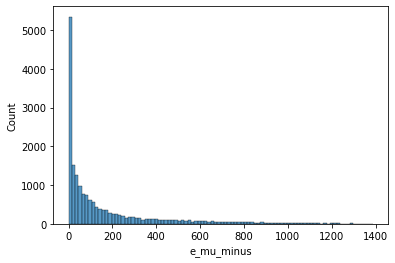

In [11]:
sns.histplot(data_selected, x='e_mu_minus')

<AxesSubplot:xlabel='e_mu_plus', ylabel='Count'>

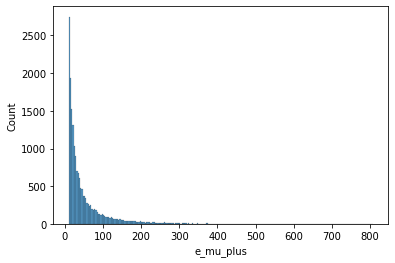

In [12]:
sns.histplot(data_selected, x='e_mu_plus')